# Phase 6 — Physics-Based Memory Persistence

This notebook turns your GPU black-hole simulator branch into a controlled memory-persistence experiment.

The question is no longer only whether a model can infer histories. The new question is:

> How long does a final black-hole observation preserve evidence of a past physical event?

The notebook injects controlled events, renders final observations with a headless simulator-compatible renderer, trains a model to recover event type and event age, then estimates a memory-persistence curve and memory half-life.

Important: your `physics_blackhole_demo.py` is an interactive pygame/moderngl simulator. This notebook records and verifies that simulator file, then uses a headless Torch renderer that mirrors its physical controls (`mass`, `spin`, `accretion`, `time`) and extends them with event channels (`jet_power`, `turbulence`, `disk_luminosity`) so the experiment can run reproducibly in a notebook.

In [15]:
# ================================================================
# 1. Imports and setup
# ================================================================

import os
import json
import math
import random
import shutil
import hashlib
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

PyTorch: 2.9.0+cu128
CUDA available: True


device(type='cuda')

In [16]:
# ================================================================
# 2. Configuration
# ================================================================

PROJECT_ROOT = Path("/home/marwa/files/phase1_blackhole_generator")
DATA_ROOT = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

GPU_SIMULATOR_PATH = PROJECT_ROOT / "physics_blackhole_demo.py"

DATASET_DIR = DATA_ROOT / "dataset_phase6_memory_persistence"
PHASE6_DIR = OUTPUT_DIR / "phase6_memory_persistence"

OVERWRITE_DATASET = True
SEED = 42
N_SAMPLES_PER_EVENT_AGE = 35
IMAGE_SIZE = 128
HISTORY_T = 160

EVENT_AGES = [0, 5, 10, 20, 40, 60, 90, 120]
EVENT_TYPES = ["accretion_burst", "jet_eruption", "turbulence_spike", "spin_transition"]
EVENT_TO_INDEX = {name: i for i, name in enumerate(EVENT_TYPES)}
INDEX_TO_EVENT = {i: name for name, i in EVENT_TO_INDEX.items()}

TARGET_COLUMNS = ["mass", "spin", "accretion", "jet_power", "turbulence", "disk_luminosity"]

BATCH_SIZE = 32
NUM_WORKERS = 2
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10
NUM_EPOCHS = 35
LEARNING_RATE = 8e-4
EARLY_STOPPING_PATIENCE = 7

NOISE_SIGMA_RANGE = (0.015, 0.11)
BLUR_SIGMA_RANGE = (0.0, 1.4)

PHASE6_DIR.mkdir(parents=True, exist_ok=True)
DATA_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

TOTAL_SAMPLES = len(EVENT_TYPES) * len(EVENT_AGES) * N_SAMPLES_PER_EVENT_AGE

print("Project root:", PROJECT_ROOT.resolve())
print("GPU simulator:", GPU_SIMULATOR_PATH.resolve())
print("GPU simulator exists:", GPU_SIMULATOR_PATH.exists())
print("Phase 6 dataset:", DATASET_DIR.resolve())
print("Phase 6 outputs:", PHASE6_DIR.resolve())
print("Samples planned:", TOTAL_SAMPLES)

Project root: /home/marwa/files/phase1_blackhole_generator
GPU simulator: /home/marwa/files/phase1_blackhole_generator/physics_blackhole_demo.py
GPU simulator exists: True
Phase 6 dataset: /home/marwa/files/phase1_blackhole_generator/data/dataset_phase6_memory_persistence
Phase 6 outputs: /home/marwa/files/phase1_blackhole_generator/outputs/phase6_memory_persistence
Samples planned: 1120


In [17]:
# ================================================================
# 3. Verify simulator and prepare folders
# ================================================================

if not GPU_SIMULATOR_PATH.exists():
    raise FileNotFoundError(
        f"Missing GPU simulator: {GPU_SIMULATOR_PATH}. Put physics_blackhole_demo.py in the project root or update GPU_SIMULATOR_PATH."
    )

sim_source = GPU_SIMULATOR_PATH.read_bytes()
simulator_sha256 = hashlib.sha256(sim_source).hexdigest()
sim_text = sim_source.decode("utf-8", errors="ignore")

print("Simulator SHA256:", simulator_sha256)
for token in ["u_mass", "u_spin", "u_accretion", "u_time"]:
    print(f"contains {token}:", token in sim_text)

subdirs = ["clean", "noisy", "metadata", "history"]

if DATASET_DIR.exists():
    existing_files = [p for p in DATASET_DIR.glob("**/*") if p.is_file()]
    if existing_files and not OVERWRITE_DATASET:
        raise RuntimeError(
            f"Phase 6 dataset already has {len(existing_files)} files. Set OVERWRITE_DATASET=True to regenerate."
        )

if OVERWRITE_DATASET and DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

for sd in subdirs:
    (DATASET_DIR / sd).mkdir(parents=True, exist_ok=True)

print("Dataset folders ready.")

Simulator SHA256: 41e00c206e5f47711d06305ba4aff5aaa65802f846682288c5f5d78aa1a2ac2a
contains u_mass: True
contains u_spin: True
contains u_accretion: True
contains u_time: True
Dataset folders ready.


In [18]:
# ================================================================
# 4. Event history generator
# ================================================================

@dataclass
class Phase6Params:
    mass: float
    spin_base: float
    accretion_base: float
    jet_base: float
    turbulence_base: float
    luminosity_base: float
    observer_angle: float
    camera_yaw: float
    camera_pitch: float
    camera_distance: float
    noise_sigma: float
    blur_sigma: float

    def to_dict(self):
        return asdict(self)


def gaussian_event(t, center, width, amplitude):
    return amplitude * np.exp(-0.5 * ((t - center) / max(width, 1e-6)) ** 2)


def smooth_noise(rng, T, scale=0.05, smooth=11):
    noise = rng.normal(0.0, scale, T).astype(np.float32)
    k = int(max(3, smooth))
    if k % 2 == 0:
        k += 1
    x = np.linspace(-2, 2, k)
    kernel = np.exp(-0.5 * x * x)
    kernel = kernel / kernel.sum()
    return np.convolve(noise, kernel, mode="same").astype(np.float32)


def generate_base_params(rng):
    return Phase6Params(
        mass=float(rng.uniform(6.0, 14.0)),
        spin_base=float(rng.uniform(0.08, 0.92)),
        accretion_base=float(rng.uniform(0.35, 1.45)),
        jet_base=float(rng.uniform(0.10, 0.70)),
        turbulence_base=float(rng.uniform(0.10, 0.80)),
        luminosity_base=float(rng.uniform(0.35, 1.20)),
        observer_angle=float(rng.uniform(0.0, 75.0)),
        camera_yaw=float(rng.uniform(-0.35, 0.35)),
        camera_pitch=float(rng.uniform(-0.20, 0.25)),
        camera_distance=float(rng.uniform(4.5, 7.0)),
        noise_sigma=float(rng.uniform(*NOISE_SIGMA_RANGE)),
        blur_sigma=float(rng.uniform(*BLUR_SIGMA_RANGE)),
    )


def generate_event_history(params, event_type, event_age, rng, T=160):
    final_t = T - 1
    center = final_t - event_age
    t = np.arange(T, dtype=np.float32)
    width = float(rng.uniform(5.0, 15.0))
    amp = float(rng.uniform(0.35, 0.95))

    mass = np.full(T, params.mass, dtype=np.float32)
    spin = np.full(T, params.spin_base, dtype=np.float32)
    accretion = np.full(T, params.accretion_base, dtype=np.float32)
    jet_power = np.full(T, params.jet_base, dtype=np.float32)
    turbulence = np.full(T, params.turbulence_base, dtype=np.float32)
    disk_luminosity = np.full(T, params.luminosity_base, dtype=np.float32)

    accretion += smooth_noise(rng, T, 0.06, 13)
    jet_power += smooth_noise(rng, T, 0.035, 15)
    turbulence += smooth_noise(rng, T, 0.05, 11)
    disk_luminosity += smooth_noise(rng, T, 0.05, 13)

    event_profile = gaussian_event(t, center, width, amp).astype(np.float32)
    age_from_center = np.maximum(t - center, 0.0)
    tail_fast = np.exp(-age_from_center / 20.0).astype(np.float32) * (t >= center)
    tail_medium = np.exp(-age_from_center / 45.0).astype(np.float32) * (t >= center)
    tail_slow = np.exp(-age_from_center / 85.0).astype(np.float32) * (t >= center)

    if event_type == "accretion_burst":
        accretion += 0.90 * event_profile + 0.22 * amp * tail_fast
        disk_luminosity += 0.55 * event_profile + 0.18 * amp * tail_fast
        turbulence += 0.14 * event_profile
        jet_power += 0.10 * event_profile
    elif event_type == "jet_eruption":
        jet_power += 0.95 * event_profile + 0.32 * amp * tail_medium
        disk_luminosity += 0.18 * event_profile
        turbulence += 0.12 * event_profile
        spin += 0.05 * amp * tail_medium
    elif event_type == "turbulence_spike":
        turbulence += 0.95 * event_profile + 0.22 * amp * tail_medium
        disk_luminosity += 0.18 * event_profile
        accretion += 0.10 * event_profile
    elif event_type == "spin_transition":
        direction = 1.0 if rng.random() > 0.5 else -1.0
        step = 1.0 / (1.0 + np.exp(-(t - center) / max(width * 0.45, 1.0)))
        spin += direction * 0.35 * amp * step
        jet_power += 0.22 * amp * tail_slow
        disk_luminosity += 0.08 * amp * tail_slow
    else:
        raise ValueError(event_type)

    disk_luminosity += 0.20 * (accretion - np.mean(accretion)) + 0.12 * (jet_power - np.mean(jet_power))

    spin = np.clip(spin, 0.0, 1.0)
    accretion = np.clip(accretion, 0.05, 2.0)
    jet_power = np.clip(jet_power, 0.0, 1.6)
    turbulence = np.clip(turbulence, 0.0, 1.6)
    disk_luminosity = np.clip(disk_luminosity, 0.05, 2.0)

    return pd.DataFrame({
        "time": np.arange(T, dtype=np.int32),
        "mass": mass,
        "spin": spin.astype(np.float32),
        "accretion": accretion.astype(np.float32),
        "jet_power": jet_power.astype(np.float32),
        "turbulence": turbulence.astype(np.float32),
        "disk_luminosity": disk_luminosity.astype(np.float32),
        "event_profile": event_profile.astype(np.float32),
        "event_center": np.full(T, center, dtype=np.float32),
        "event_age": np.full(T, event_age, dtype=np.float32),
    })

In [19]:
# ================================================================
# 5. Headless simulator-compatible renderer
# ================================================================

_RENDER_CACHE = {}


def get_grid(size, device):
    key = (size, str(device))
    if key in _RENDER_CACHE:
        return _RENDER_CACHE[key]
    axis = torch.linspace(-1.0, 1.0, size, device=device)
    y, x = torch.meshgrid(axis, axis, indexing="ij")
    r = torch.sqrt(x * x + y * y + 1e-8)
    phi = torch.atan2(y, x)
    _RENDER_CACHE[key] = (x, y, r, phi)
    return x, y, r, phi


def recent_summary(history_df, window=18):
    recent = history_df.tail(window)
    final = history_df.iloc[-1]
    return {
        "mass": float(final["mass"]),
        "spin": float(recent["spin"].mean()),
        "spin_final": float(final["spin"]),
        "accretion": float(recent["accretion"].mean()),
        "jet_power": float(recent["jet_power"].mean()),
        "turbulence": float(recent["turbulence"].mean()),
        "disk_luminosity": float(recent["disk_luminosity"].mean()),
        "event_profile_recent": float(recent["event_profile"].mean()),
        "event_age": float(final["event_age"]),
        "event_center": float(final["event_center"]),
    }


def render_simulator_frame(params, history_df, size=128, device=DEVICE):
    h = recent_summary(history_df)
    x, y, r, phi = get_grid(size, device)

    mass = torch.tensor(h["mass"], device=device)
    spin = torch.tensor(h["spin"], device=device)
    spin_final = torch.tensor(h["spin_final"], device=device)
    acc = torch.tensor(h["accretion"], device=device)
    jet_power = torch.tensor(h["jet_power"], device=device)
    turb_level = torch.tensor(h["turbulence"], device=device)
    lum = torch.tensor(h["disk_luminosity"], device=device)
    event_recent = torch.tensor(h["event_profile_recent"], device=device)

    observer_angle = torch.tensor(float(params.observer_angle) * math.pi / 180.0, device=device)
    yaw = torch.tensor(float(params.camera_yaw), device=device)

    cos_i = torch.clamp(torch.cos(observer_angle), min=0.30)
    x_cam = x * torch.cos(yaw) - y * torch.sin(yaw)
    y_cam = x * torch.sin(yaw) + y * torch.cos(yaw)
    y_inc = y_cam / cos_i

    spin_shift = 0.035 * (spin_final - 0.5)
    x_shift = x_cam - spin_shift
    r_inc = torch.sqrt(x_shift * x_shift + y_inc * y_inc + 1e-8)
    phi_inc = torch.atan2(y_inc, x_shift)

    shadow_radius = 0.095 + 0.010 * (mass / 10.0)
    shadow_edge = 0.014 + 0.006 * jet_power
    shadow_mask = torch.clamp((r - shadow_radius) / shadow_edge, 0.0, 1.0)

    warp = 0.018 * spin * torch.sin(phi_inc - spin * math.pi)
    warp += 0.012 * turb_level * torch.sin(3.0 * phi_inc + spin * 2.0 * math.pi)
    ring_radius = 0.175 + 0.012 * (mass / 10.0 - 1.0) + warp
    ring_width = 0.025 + 0.010 * jet_power
    ring = torch.exp(-0.5 * ((r_inc - ring_radius) / ring_width) ** 2)
    ring *= 1.0 + (0.40 + 0.55 * spin) * torch.sin(observer_angle) * torch.cos(phi_inc - spin * math.pi)

    inner = 0.16 + 0.010 * (mass / 10.0 - 1.0)
    outer = 0.76 + 0.08 * lum
    disk_mask = torch.sigmoid((r_inc - inner) / 0.018) * torch.sigmoid((outer - r_inc) / 0.04)
    radial = torch.exp(-2.6 * torch.clamp((r_inc - inner) / (outer - inner + 1e-6), 0.0, 2.0))
    disk = disk_mask * radial * (0.45 + 0.65 * lum) * (0.55 + 0.45 * acc)

    texture = torch.zeros_like(r)
    for k in range(1, 9):
        phase = 0.8 * k + 0.13 * h["event_center"]
        texture += torch.sin((2.0 + k * 1.7) * phi_inc + phase) * torch.cos((3.0 + k * 0.85) * r_inc * math.pi + phase)
    texture = texture / 8.0
    disk = disk * (1.0 + (0.20 + 0.35 * turb_level) * texture)

    clumps = torch.zeros_like(r)
    for k in range(4):
        angle = 1.3 * k + 0.07 * h["event_center"] + float(spin.detach().cpu())
        rr = 0.25 + 0.09 * k
        dphi = torch.atan2(torch.sin(phi_inc - angle), torch.cos(phi_inc - angle))
        clumps += torch.exp(-0.5 * ((r_inc - rr) / 0.045) ** 2) * torch.exp(-0.5 * (dphi / 0.23) ** 2)
    disk = disk + 0.22 * torch.clamp(0.30 * turb_level + 0.75 * event_recent, 0.0, 1.4) * clumps * disk_mask

    tilt = (spin - 0.5) * 0.40 + yaw * 0.25
    x_rot = x * torch.cos(tilt) - y * torch.sin(tilt)
    y_rot = x * torch.sin(tilt) + y * torch.cos(tilt)
    jet_width = 0.035 + 0.035 * torch.clamp(jet_power, 0.0, 1.5)
    jet_len = 0.42 + 0.26 * torch.clamp(jet_power, 0.0, 1.5)
    upper = torch.exp(-0.5 * (x_rot / jet_width) ** 2) * torch.exp(-torch.clamp(y_rot, min=0.0) / jet_len) * (y_rot > 0.14).float()
    lower = torch.exp(-0.5 * (x_rot / (jet_width * 1.15)) ** 2) * torch.exp(-torch.clamp(-y_rot, min=0.0) / (jet_len * 0.9)) * (y_rot < -0.14).float()
    jet = (upper + 0.75 * lower) * (0.15 + 0.75 * jet_power) * (0.35 + 0.65 * torch.sin(observer_angle))

    glow = torch.exp(-((r_inc / (0.55 + 0.12 * lum)) ** 2)) * (0.06 + 0.16 * lum)
    image = (0.74 * disk + 0.92 * ring + 0.55 * jet + glow) * shadow_mask
    image = torch.clamp(image, min=0.0)
    image = image / (image.max() + 1e-6)
    return torch.clamp(image, 0.0, 1.0).detach().float().cpu().numpy()


def gaussian_blur_numpy(image, sigma):
    if sigma <= 1e-8:
        return image.astype(np.float32)
    radius = int(max(1, round(3 * sigma)))
    xs = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (xs / sigma) ** 2)
    kernel = kernel / kernel.sum()
    temp = np.apply_along_axis(lambda m: np.convolve(m, kernel, mode="same"), 0, image)
    out = np.apply_along_axis(lambda m: np.convolve(m, kernel, mode="same"), 1, temp)
    return out.astype(np.float32)


def corrupt_observation(clean, params, rng):
    image = gaussian_blur_numpy(clean.astype(np.float32), params.blur_sigma)
    image += rng.normal(0.0, params.noise_sigma, image.shape).astype(np.float32)
    return np.clip(image, 0.0, 1.0).astype(np.float32)


def save_png01(arr, path):
    Image.fromarray((np.clip(arr, 0.0, 1.0) * 255).astype(np.uint8)).save(path)

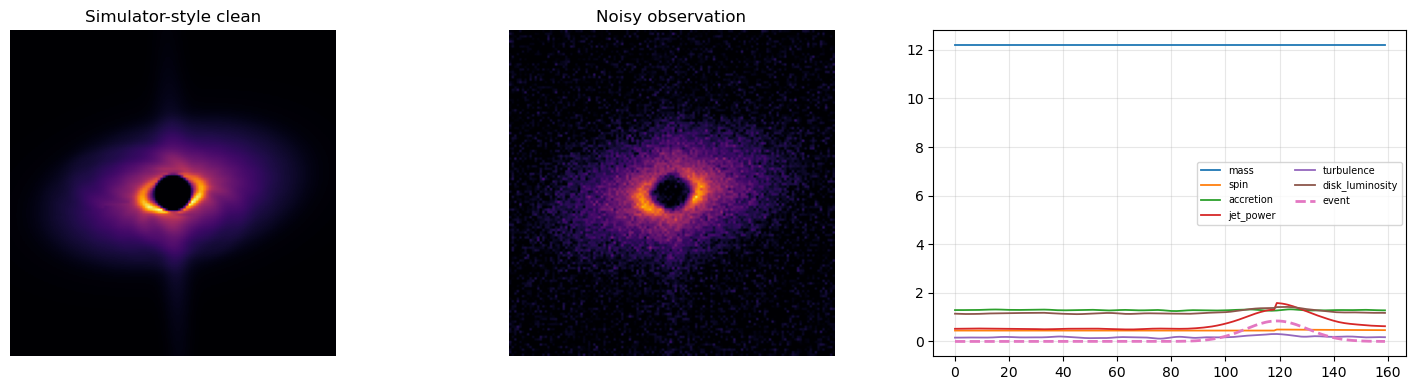

Phase6Params(mass=12.191648388447707, spin_base=0.448657889391724, accretion_base=1.294457711902521, jet_base=0.5184208174356183, turbulence_base=0.16592414352135468, luminosity_base=1.1792789988912427, observer_angle=57.08547764927647, camera_yaw=0.2002450136938676, camera_pitch=-0.14234886529600438, camera_distance=5.625964844738918, noise_sigma=0.05022581230209522, blur_sigma=1.2974709843880425)
{'mass': 12.191648483276367, 'spin': 0.46974480152130127, 'spin_final': 0.4659997820854187, 'accretion': 1.2918490171432495, 'jet_power': 0.6892148852348328, 'turbulence': 0.18417423963546753, 'disk_luminosity': 1.1865891218185425, 'event_profile_recent': 0.03273122012615204, 'event_age': 40.0, 'event_center': 119.0}


In [20]:
# ================================================================
# 6. Smoke test
# ================================================================

smoke_rng = np.random.default_rng(SEED)
smoke_params = generate_base_params(smoke_rng)
smoke_history = generate_event_history(smoke_params, "jet_eruption", 40, smoke_rng, HISTORY_T)
smoke_clean = render_simulator_frame(smoke_params, smoke_history, IMAGE_SIZE, DEVICE)
smoke_noisy = corrupt_observation(smoke_clean, smoke_params, smoke_rng)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(smoke_clean, cmap="inferno", vmin=0, vmax=1)
axes[0].set_title("Simulator-style clean")
axes[0].axis("off")
axes[1].imshow(smoke_noisy, cmap="inferno", vmin=0, vmax=1)
axes[1].set_title("Noisy observation")
axes[1].axis("off")
for col in TARGET_COLUMNS:
    axes[2].plot(smoke_history["time"].to_numpy(), smoke_history[col].to_numpy(), label=col, linewidth=1.3)
axes[2].plot(smoke_history["time"].to_numpy(), smoke_history["event_profile"].to_numpy(), "--", label="event", linewidth=2.0)
axes[2].grid(alpha=0.3)
axes[2].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

print(smoke_params)
print(recent_summary(smoke_history))

In [21]:
# ================================================================
# 7. Generate dataset
# ================================================================

rows = []
sample_index = 0

for event_type in EVENT_TYPES:
    for event_age in EVENT_AGES:
        for rep in range(N_SAMPLES_PER_EVENT_AGE):
            sample_index += 1
            sample_id = f"p6_{sample_index:05d}"
            sample_rng = np.random.default_rng(SEED + sample_index * 17)

            params = generate_base_params(sample_rng)
            history = generate_event_history(params, event_type, event_age, sample_rng, HISTORY_T)
            clean = render_simulator_frame(params, history, IMAGE_SIZE, DEVICE)
            noisy = corrupt_observation(clean, params, sample_rng)

            save_png01(clean, DATASET_DIR / "clean" / f"{sample_id}.png")
            save_png01(noisy, DATASET_DIR / "noisy" / f"{sample_id}_noisy.png")
            history.to_csv(DATASET_DIR / "history" / f"{sample_id}.csv", index=False)

            summary = recent_summary(history)
            metadata = {
                "sample_id": sample_id,
                "sample_index": sample_index,
                "event_type": event_type,
                "event_type_index": EVENT_TO_INDEX[event_type],
                "event_age": event_age,
                "event_center": int(HISTORY_T - 1 - event_age),
                "params": params.to_dict(),
                "recent_summary": summary,
                "renderer": "phase6_headless_torch_renderer_compatible_with_gpu_simulator_controls",
                "gpu_simulator_path": str(GPU_SIMULATOR_PATH),
                "gpu_simulator_sha256": simulator_sha256,
            }
            with open(DATASET_DIR / "metadata" / f"{sample_id}.json", "w") as f:
                json.dump(metadata, f, indent=2)

            row = params.to_dict()
            row.update(summary)
            row.update({
                "sample_id": sample_id,
                "sample_index": sample_index,
                "event_type": event_type,
                "event_type_index": EVENT_TO_INDEX[event_type],
                "event_age": event_age,
                "event_center": int(HISTORY_T - 1 - event_age),
            })
            rows.append(row)

            if sample_index % 100 == 0:
                print(f"Generated {sample_index}/{TOTAL_SAMPLES}")

params_df = pd.DataFrame(rows)
params_df.to_csv(DATASET_DIR / "params_table.csv", index=False)
print("Done:", len(params_df))
display(params_df.head())

Generated 100/1120
Generated 200/1120
Generated 300/1120
Generated 400/1120
Generated 500/1120
Generated 600/1120
Generated 700/1120
Generated 800/1120
Generated 900/1120
Generated 1000/1120
Generated 1100/1120
Done: 1120


,mass,spin_base,accretion_base,jet_base,turbulence_base,luminosity_base,observer_angle,camera_yaw,camera_pitch,camera_distance,...,jet_power,turbulence,disk_luminosity,event_profile_recent,event_age,event_center,sample_id,sample_index,event_type,event_type_index
0,10.701978,0.773896,0.478638,0.326458,0.230384,0.486240,0.436469,0.330855,-0.153351,6.836295,...,0.368827,0.270658,0.710300,0.294393,0,159,p6_00001,1,accretion_burst,0
1,12.450652,0.907840,1.100640,0.532531,0.154680,0.612558,42.129864,0.326721,-0.099558,5.374476,...,0.560022,0.191374,0.835475,0.301307,0,159,p6_00002,2,accretion_burst,0
2,13.883923,0.536270,0.855293,0.360879,0.564212,0.398242,72.902503,-0.041671,0.143898,4.581893,...,0.397768,0.601976,0.665426,0.365520,0,159,p6_00003,3,accretion_burst,0
3,13.443942,0.510448,1.133776,0.401334,0.267895,1.094901,5.160053,0.141838,-0.155945,5.614198,...,0.421727,0.326509,1.326374,0.307380,0,159,p6_00004,4,accretion_burst,0
4,6.499732,0.256092,0.679266,0.646034,0.321586,0.847696,71.984299,0.219969,-0.079398,4.618977,...,0.703728,0.392102,1.198455,0.490090,0,159,p6_00005,5,accretion_burst,0


In [22]:
# ================================================================
# 8. Manifest and integrity checks
# ================================================================

manifest = {
    "dataset_name": "phase6_physics_based_memory_persistence_dataset",
    "version": "6.0",
    "n_samples": int(len(params_df)),
    "image_size": IMAGE_SIZE,
    "history_T": HISTORY_T,
    "seed": SEED,
    "event_types": EVENT_TYPES,
    "event_ages": EVENT_AGES,
    "target_columns": TARGET_COLUMNS,
    "gpu_simulator_path": str(GPU_SIMULATOR_PATH),
    "gpu_simulator_sha256": simulator_sha256,
    "renderer": "headless_torch_renderer_mirroring_gpu_simulator_controls",
    "scientific_question": "How long does a final black-hole image retain recoverable evidence of a past physical event?",
}

with open(DATASET_DIR / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

for sd in ["clean", "noisy", "metadata", "history"]:
    files = sorted((DATASET_DIR / sd).glob("*"))
    print(sd, len(files))
    assert len(files) == TOTAL_SAMPLES

assert (DATASET_DIR / "params_table.csv").exists()
assert (DATASET_DIR / "manifest.json").exists()
print("Integrity checks passed.")

clean 1120
noisy 1120


metadata 1120
history 1120
Integrity checks passed.


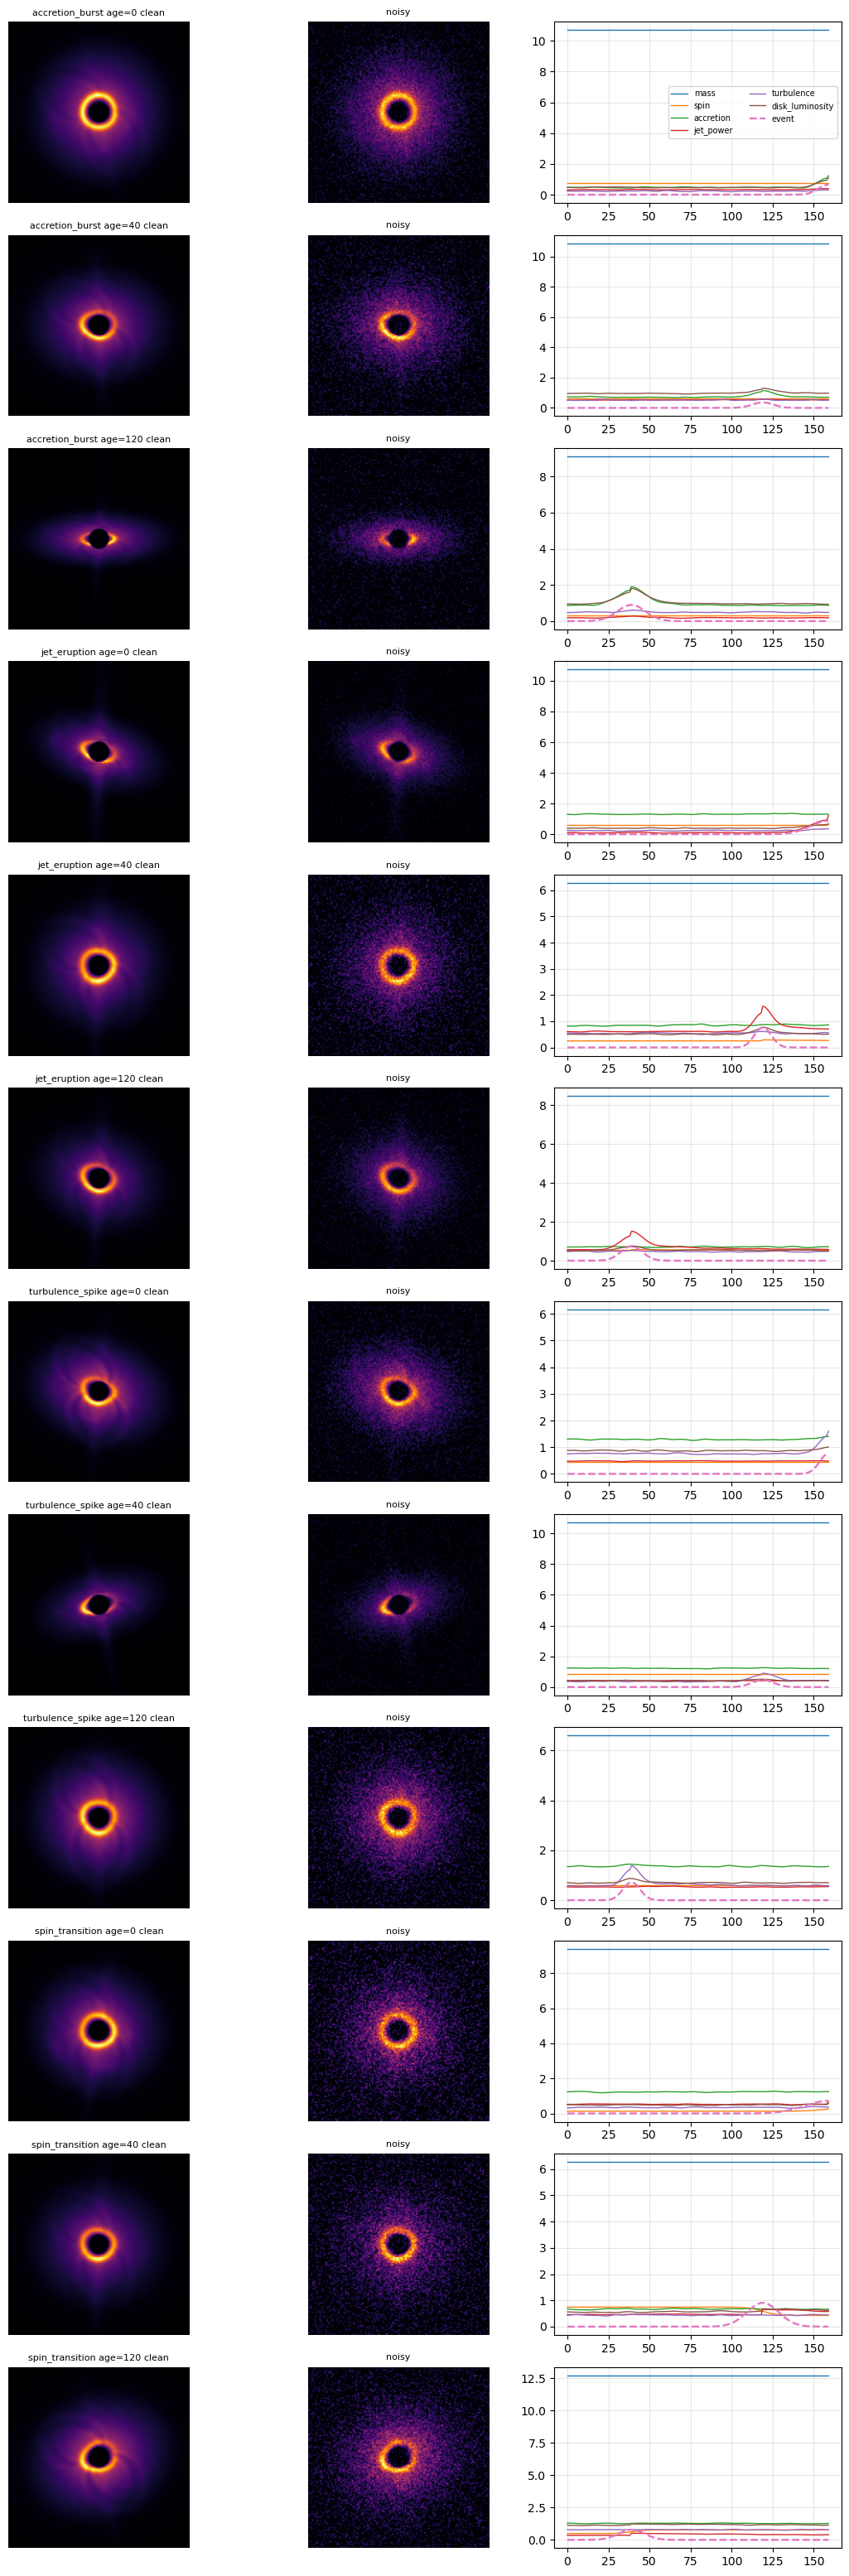

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6_memory_persistence/phase6_dataset_visual_inspection.png


In [23]:
# ================================================================
# 9. Visual inspection
# ================================================================

def load_image01(path):
    return np.asarray(Image.open(path).convert("L"), dtype=np.float32) / 255.0

inspect_rows = []
for event_type in EVENT_TYPES:
    for event_age in [EVENT_AGES[0], EVENT_AGES[len(EVENT_AGES)//2], EVENT_AGES[-1]]:
        subset = params_df[(params_df["event_type"] == event_type) & (params_df["event_age"] == event_age)]
        inspect_rows.append(subset.iloc[0])

fig, axes = plt.subplots(len(inspect_rows), 3, figsize=(11, 2.6 * len(inspect_rows)))
for row_idx, row in enumerate(inspect_rows):
    sid = row["sample_id"]
    clean = load_image01(DATASET_DIR / "clean" / f"{sid}.png")
    noisy = load_image01(DATASET_DIR / "noisy" / f"{sid}_noisy.png")
    hist = pd.read_csv(DATASET_DIR / "history" / f"{sid}.csv")
    axes[row_idx, 0].imshow(clean, cmap="inferno", vmin=0, vmax=1)
    axes[row_idx, 0].set_title(f"{row['event_type']} age={row['event_age']} clean", fontsize=8)
    axes[row_idx, 0].axis("off")
    axes[row_idx, 1].imshow(noisy, cmap="inferno", vmin=0, vmax=1)
    axes[row_idx, 1].set_title("noisy", fontsize=8)
    axes[row_idx, 1].axis("off")
    for col in TARGET_COLUMNS:
        axes[row_idx, 2].plot(hist["time"].to_numpy(), hist[col].to_numpy(), linewidth=1.0, label=col)
    axes[row_idx, 2].plot(hist["time"].to_numpy(), hist["event_profile"].to_numpy(), "--", linewidth=1.7, label="event")
    axes[row_idx, 2].grid(alpha=0.3)
axes[0, 2].legend(fontsize=7, ncol=2)
plt.tight_layout()
inspection_path = PHASE6_DIR / "phase6_dataset_visual_inspection.png"
plt.savefig(inspection_path, dpi=150)
plt.show()
print("Saved:", inspection_path)

In [24]:
# ================================================================
# 10. Dataset class and loaders
# ================================================================

class Phase6MemoryDataset(Dataset):
    def __init__(self, dataset_dir, input_mode="noisy"):
        self.dataset_dir = Path(dataset_dir)
        self.input_mode = input_mode
        self.params = pd.read_csv(self.dataset_dir / "params_table.csv")
        self.clean_dir = self.dataset_dir / "clean"
        self.noisy_dir = self.dataset_dir / "noisy"

    def __len__(self):
        return len(self.params)

    def _load_image(self, sample_id):
        if self.input_mode == "clean":
            path = self.clean_dir / f"{sample_id}.png"
        elif self.input_mode == "noisy":
            path = self.noisy_dir / f"{sample_id}_noisy.png"
        else:
            raise ValueError(self.input_mode)
        arr = np.asarray(Image.open(path).convert("L"), dtype=np.float32) / 255.0
        return torch.from_numpy(arr).unsqueeze(0)

    def __getitem__(self, idx):
        row = self.params.iloc[idx]
        sample_id = row["sample_id"]
        image = self._load_image(sample_id)
        event_type = torch.tensor(int(row["event_type_index"]), dtype=torch.long)
        event_age = torch.tensor([float(row["event_age"]) / max(EVENT_AGES)], dtype=torch.float32)
        return image, event_type, event_age, sample_id

INPUT_MODE = "clean"  # change to "clean" for an ideal-observation run
memory_dataset = Phase6MemoryDataset(DATASET_DIR, input_mode=INPUT_MODE)

n_total = len(memory_dataset)
n_train = int(TRAIN_RATIO * n_total)
n_val = int(VAL_RATIO * n_total)
n_test = n_total - n_train - n_val

generator = torch.Generator().manual_seed(SEED)
train_ds, val_ds, test_ds = random_split(memory_dataset, [n_train, n_val, n_test], generator=generator)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

Train: 896 Val: 112 Test: 112


In [25]:
# ================================================================
# 11. Memory persistence model
# ================================================================

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class Phase6MemoryNet(nn.Module):
    def __init__(self, num_events=4, base=32, dropout=0.20):
        super().__init__()
        self.stem = ConvBlock(1, base)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base, base * 2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base * 2, base * 4))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base * 4, base * 8))
        self.down4 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base * 8, base * 8))
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(base * 8, 256), nn.SiLU(inplace=True), nn.Dropout(dropout))
        self.type_head = nn.Linear(256, num_events)
        self.age_head = nn.Sequential(nn.Linear(256, 1), nn.Sigmoid())
    def forward(self, x):
        x = self.stem(x)
        x = self.down1(x)
        x = self.down2(x)
        x = self.down3(x)
        x = self.down4(x)
        z = self.head(self.pool(x))
        return self.type_head(z), self.age_head(z)

model = Phase6MemoryNet(num_events=len(EVENT_TYPES)).to(DEVICE)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable parameters: 2420389


In [26]:
# ================================================================
# 12. Training utilities
# ================================================================

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)
TYPE_LOSS_WEIGHT = 1.0
AGE_LOSS_WEIGHT = 0.65


def compute_loss(logits, pred_age, true_type, true_age):
    type_loss = F.cross_entropy(logits, true_type)
    age_loss = F.smooth_l1_loss(pred_age, true_age)
    return TYPE_LOSS_WEIGHT * type_loss + AGE_LOSS_WEIGHT * age_loss, type_loss, age_loss


def r2_score_np(pred, true):
    pred = np.asarray(pred).reshape(-1)
    true = np.asarray(true).reshape(-1)
    ss_res = np.sum((true - pred) ** 2)
    ss_tot = np.sum((true - true.mean()) ** 2) + 1e-8
    return float(1.0 - ss_res / ss_tot)


def train_one_epoch(model, loader):
    model.train()
    total = 0.0
    for image, event_type, event_age, _ in loader:
        image = image.to(DEVICE, non_blocking=True)
        event_type = event_type.to(DEVICE, non_blocking=True)
        event_age = event_age.to(DEVICE, non_blocking=True)
        logits, pred_age = model(image)
        loss, _, _ = compute_loss(logits, pred_age, event_type, event_age)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item() * image.size(0)
    return total / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    losses, accs = [], []
    all_sids, true_types, pred_types, true_ages, pred_ages = [], [], [], [], []
    for image, event_type, event_age, sample_ids in loader:
        image = image.to(DEVICE, non_blocking=True)
        event_type = event_type.to(DEVICE, non_blocking=True)
        event_age = event_age.to(DEVICE, non_blocking=True)
        logits, pred_age = model(image)
        loss, _, _ = compute_loss(logits, pred_age, event_type, event_age)
        pred_type = logits.argmax(dim=1)
        losses.append(loss.item())
        accs.append((pred_type == event_type).float().mean().item())
        all_sids.extend(list(sample_ids))
        true_types.extend(event_type.cpu().numpy().tolist())
        pred_types.extend(pred_type.cpu().numpy().tolist())
        true_ages.extend((event_age.cpu().numpy().reshape(-1) * max(EVENT_AGES)).tolist())
        pred_ages.extend((pred_age.cpu().numpy().reshape(-1) * max(EVENT_AGES)).tolist())
    true_ages_np = np.array(true_ages)
    pred_ages_np = np.array(pred_ages)
    return {
        "loss": float(np.mean(losses)),
        "type_accuracy": float(np.mean(accs)),
        "age_mae": float(np.mean(np.abs(true_ages_np - pred_ages_np))),
        "age_r2": r2_score_np(pred_ages_np, true_ages_np),
        "sample_ids": all_sids,
        "true_type": true_types,
        "pred_type": pred_types,
        "true_age": true_ages,
        "pred_age": pred_ages,
    }

In [27]:
# ================================================================
# 13. Train model
# ================================================================

best_val_loss = float("inf")
patience = 0
history = []
best_model_path = PHASE6_DIR / f"best_phase6_memory_model_{INPUT_MODE}.pt"

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader)
    val_metrics = evaluate(model, val_loader)
    scheduler.step(val_metrics["loss"])
    lr = optimizer.param_groups[0]["lr"]
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_type_accuracy": val_metrics["type_accuracy"],
        "val_age_mae": val_metrics["age_mae"],
        "val_age_r2": val_metrics["age_r2"],
        "lr": lr,
    }
    history.append(row)
    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        patience = 0
        torch.save({"model_state_dict": model.state_dict(), "epoch": epoch, "val_loss": best_val_loss, "input_mode": INPUT_MODE}, best_model_path)
        best_flag = " <-- best"
    else:
        patience += 1
        best_flag = ""
    print(f"Epoch {epoch:03d}/{NUM_EPOCHS} | train={train_loss:.4f} | val={val_metrics['loss']:.4f} | acc={val_metrics['type_accuracy']:.3f} | age_MAE={val_metrics['age_mae']:.2f} | age_R2={val_metrics['age_r2']:.3f} | lr={lr:.2e}{best_flag}")
    if patience >= EARLY_STOPPING_PATIENCE:
        print("Early stopping.")
        break

history_df = pd.DataFrame(history)
history_path = PHASE6_DIR / f"phase6_training_history_{INPUT_MODE}.csv"
history_df.to_csv(history_path, index=False)
print("Saved:", history_path)
print("Saved:", best_model_path)

Epoch 001/35 | train=1.4283 | val=1.5018 | acc=0.203 | age_MAE=38.23 | age_R2=-0.008 | lr=8.00e-04 <-- best
Epoch 002/35 | train=1.4058 | val=1.4606 | acc=0.219 | age_MAE=36.85 | age_R2=0.011 | lr=8.00e-04 <-- best
Epoch 003/35 | train=1.3908 | val=1.4459 | acc=0.219 | age_MAE=36.80 | age_R2=0.025 | lr=8.00e-04 <-- best
Epoch 004/35 | train=1.3767 | val=2.3604 | acc=0.320 | age_MAE=34.82 | age_R2=0.029 | lr=8.00e-04
Epoch 005/35 | train=1.3741 | val=1.5104 | acc=0.234 | age_MAE=38.60 | age_R2=-0.026 | lr=8.00e-04
Epoch 006/35 | train=1.3593 | val=1.9545 | acc=0.336 | age_MAE=35.72 | age_R2=-0.309 | lr=8.00e-04
Epoch 007/35 | train=1.3482 | val=1.5232 | acc=0.258 | age_MAE=36.47 | age_R2=0.019 | lr=8.00e-04
Epoch 008/35 | train=1.3150 | val=1.6081 | acc=0.297 | age_MAE=36.28 | age_R2=0.040 | lr=4.00e-04
Epoch 009/35 | train=1.3096 | val=1.4381 | acc=0.328 | age_MAE=36.76 | age_R2=0.020 | lr=4.00e-04 <-- best
Epoch 010/35 | train=1.2832 | val=1.4295 | acc=0.352 | age_MAE=34.31 | age_R2=0

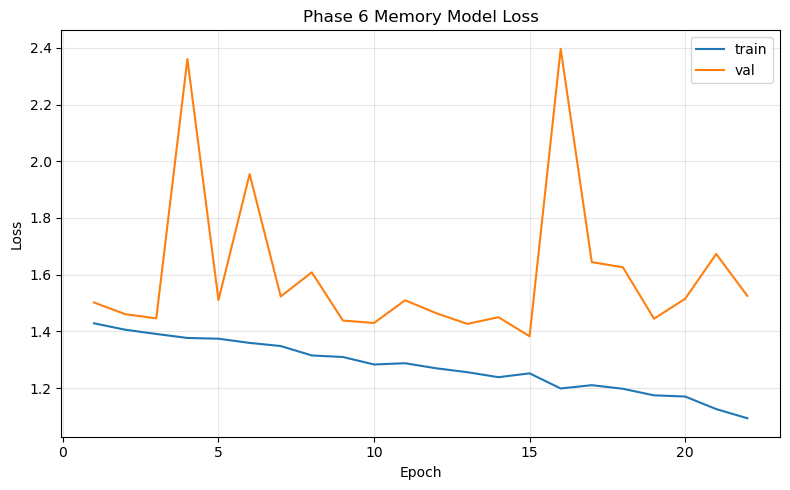

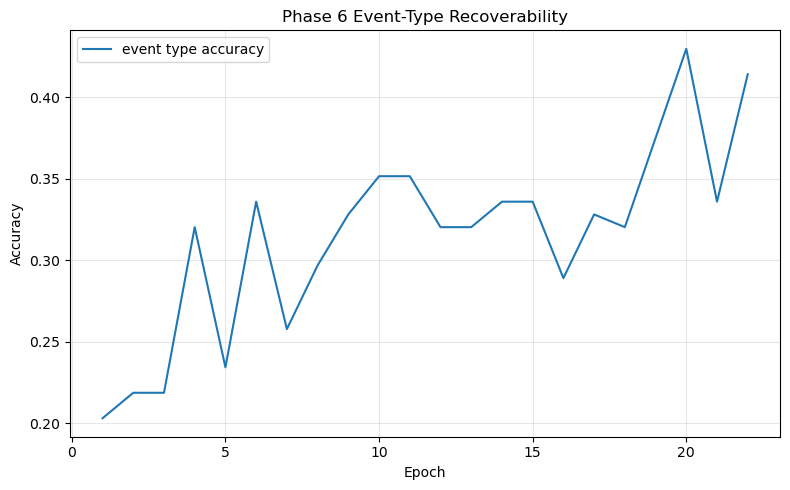

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6_memory_persistence/phase6_loss_curve_clean.png
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6_memory_persistence/phase6_type_accuracy_curve_clean.png


In [28]:
# ================================================================
# 14. Training curves
# ================================================================

history_df = pd.DataFrame(history)
epochs = history_df["epoch"].to_numpy()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_df["train_loss"].to_numpy(), label="train")
plt.plot(epochs, history_df["val_loss"].to_numpy(), label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Phase 6 Memory Model Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
loss_plot_path = PHASE6_DIR / f"phase6_loss_curve_{INPUT_MODE}.png"
plt.savefig(loss_plot_path, dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_df["val_type_accuracy"].to_numpy(), label="event type accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Phase 6 Event-Type Recoverability")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
acc_plot_path = PHASE6_DIR / f"phase6_type_accuracy_curve_{INPUT_MODE}.png"
plt.savefig(acc_plot_path, dpi=150)
plt.show()

print("Saved:", loss_plot_path)
print("Saved:", acc_plot_path)

In [29]:
# ================================================================
# 15. Test evaluation
# ================================================================

checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_metrics = evaluate(model, test_loader)
print("Test loss:", test_metrics["loss"])
print("Type accuracy:", test_metrics["type_accuracy"])
print("Age MAE frames:", test_metrics["age_mae"])
print("Age R2:", test_metrics["age_r2"])

pred_df = pd.DataFrame({
    "sample_id": test_metrics["sample_ids"],
    "true_type_index": test_metrics["true_type"],
    "pred_type_index": test_metrics["pred_type"],
    "true_age": test_metrics["true_age"],
    "pred_age": test_metrics["pred_age"],
})
pred_df["true_event_type"] = pred_df["true_type_index"].map(INDEX_TO_EVENT)
pred_df["pred_event_type"] = pred_df["pred_type_index"].map(INDEX_TO_EVENT)
pred_df["correct_type"] = pred_df["true_type_index"] == pred_df["pred_type_index"]
pred_df["age_abs_error"] = np.abs(pred_df["true_age"] - pred_df["pred_age"])
pred_df = pred_df.merge(params_df, on="sample_id", how="left")

pred_path = PHASE6_DIR / f"phase6_test_predictions_{INPUT_MODE}.csv"
pred_df.to_csv(pred_path, index=False)
metrics_path = PHASE6_DIR / f"phase6_test_metrics_{INPUT_MODE}.json"
with open(metrics_path, "w") as f:
    json.dump({k: v for k, v in test_metrics.items() if k not in ["sample_ids", "true_type", "pred_type", "true_age", "pred_age"]}, f, indent=2)

display(pred_df.head())
print("Saved:", pred_path)
print("Saved:", metrics_path)

Test loss: 1.2838986217975616
Type accuracy: 0.421875
Age MAE frames: 31.779893134321487
Age R2: 0.15461967768127394


,sample_id,true_type_index,pred_type_index,true_age,pred_age,true_event_type,pred_event_type,correct_type,age_abs_error,mass,...,accretion,jet_power,turbulence,disk_luminosity,event_profile_recent,event_age,event_center,sample_index,event_type,event_type_index
0,p6_00745,2,0,60.0,52.091713,turbulence_spike,accretion_burst,False,7.908287,8.836098,...,1.140238,0.356654,0.342325,0.797111,1.008745e-06,60,99,745,turbulence_spike,2
1,p6_00565,2,2,0.0,31.756708,turbulence_spike,turbulence_spike,True,31.756708,8.078439,...,0.832747,0.421071,0.903043,0.962958,4.518788e-01,0,159,565,turbulence_spike,2
2,p6_00400,1,1,20.0,32.104847,jet_eruption,jet_eruption,True,12.104847,13.769351,...,1.329003,0.815694,0.327486,0.685910,3.036658e-01,20,139,400,jet_eruption,1
3,p6_00592,2,2,0.0,44.520229,turbulence_spike,turbulence_spike,True,44.520229,9.473547,...,1.246874,0.643863,0.814716,0.680351,2.701721e-01,0,159,592,turbulence_spike,2
4,p6_00507,1,3,90.0,52.492176,jet_eruption,spin_transition,False,37.507824,6.725646,...,1.324625,0.281786,0.120638,0.800325,4.205205e-20,90,69,507,jet_eruption,1


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6_memory_persistence/phase6_test_predictions_clean.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6_memory_persistence/phase6_test_metrics_clean.json


,event_age,type_accuracy,age_mae,n
0,0.0,0.523810,39.533222,21
1,5.0,0.625000,29.236837,8
2,10.0,0.562500,23.990675,16
3,20.0,0.363636,18.691838,11
4,40.0,0.461538,8.428353,13
5,60.0,0.352941,11.179319,17
6,90.0,0.333333,40.419971,9
7,120.0,0.235294,73.082231,17


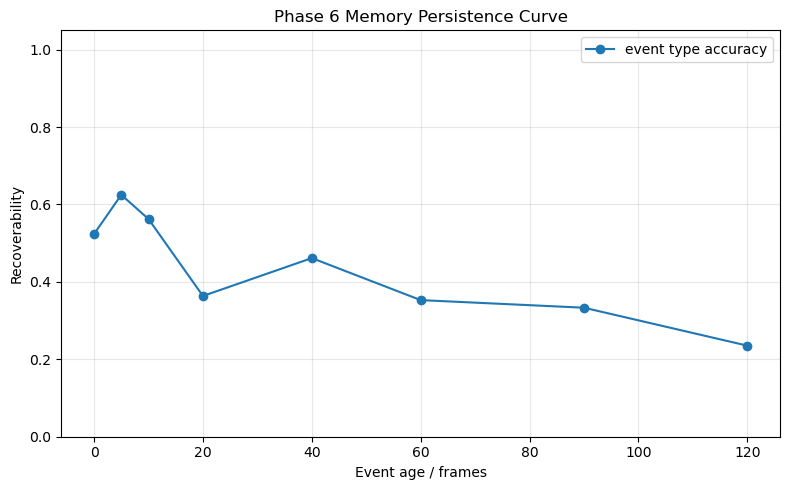

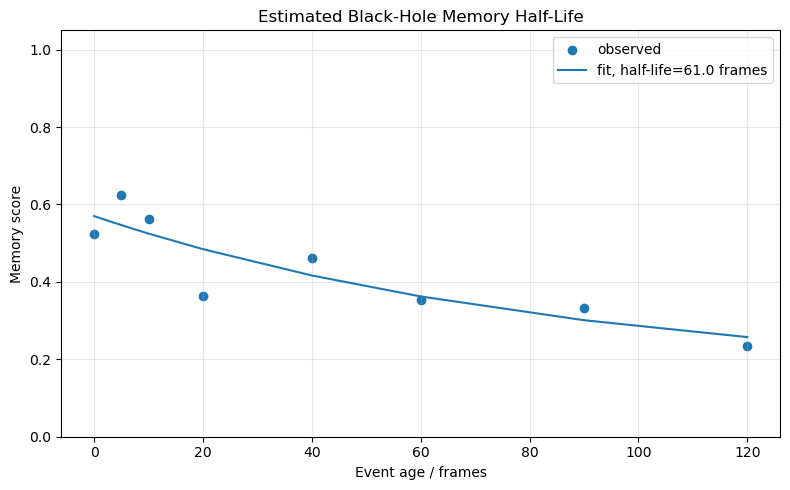

Memory half-life frames: 60.99695188927519
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6_memory_persistence/phase6_memory_curve_by_age_clean.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6_memory_persistence/phase6_memory_persistence_curve_clean.png
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6_memory_persistence/phase6_memory_half_life_fit_clean.png


In [30]:
# ================================================================
# 16. Memory persistence curves and half-life
# ================================================================

age_rows = []
for age in sorted(pred_df["event_age"].unique()):
    subset = pred_df[pred_df["event_age"] == age]
    age_rows.append({
        "event_age": float(age),
        "type_accuracy": float(subset["correct_type"].mean()),
        "age_mae": float(subset["age_abs_error"].mean()),
        "n": int(len(subset)),
    })
age_curve_df = pd.DataFrame(age_rows)
age_curve_path = PHASE6_DIR / f"phase6_memory_curve_by_age_{INPUT_MODE}.csv"
age_curve_df.to_csv(age_curve_path, index=False)
display(age_curve_df)

plt.figure(figsize=(8, 5))
plt.plot(age_curve_df["event_age"].to_numpy(), age_curve_df["type_accuracy"].to_numpy(), marker="o", label="event type accuracy")
plt.xlabel("Event age / frames")
plt.ylabel("Recoverability")
plt.ylim(0, 1.05)
plt.title("Phase 6 Memory Persistence Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
memory_curve_plot_path = PHASE6_DIR / f"phase6_memory_persistence_curve_{INPUT_MODE}.png"
plt.savefig(memory_curve_plot_path, dpi=150)
plt.show()

ages = age_curve_df["event_age"].to_numpy(dtype=np.float32)
scores = age_curve_df["type_accuracy"].to_numpy(dtype=np.float32)
best = None
for floor in np.linspace(0.0, 0.45, 46):
    for amp in np.linspace(0.05, 1.0, 96):
        for tau in np.linspace(5.0, 180.0, 176):
            pred = np.clip(floor + amp * np.exp(-ages / tau), 0.0, 1.0)
            mse = np.mean((scores - pred) ** 2)
            if best is None or mse < best[0]:
                best = (mse, floor, amp, tau)
fit_mse, fit_floor, fit_amp, fit_tau = best
memory_half_life = fit_tau * math.log(2.0)
fit_scores = np.clip(fit_floor + fit_amp * np.exp(-ages / fit_tau), 0.0, 1.0)

plt.figure(figsize=(8, 5))
plt.scatter(ages, scores, label="observed")
plt.plot(ages, fit_scores, label=f"fit, half-life={memory_half_life:.1f} frames")
plt.xlabel("Event age / frames")
plt.ylabel("Memory score")
plt.ylim(0, 1.05)
plt.title("Estimated Black-Hole Memory Half-Life")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
halflife_plot_path = PHASE6_DIR / f"phase6_memory_half_life_fit_{INPUT_MODE}.png"
plt.savefig(halflife_plot_path, dpi=150)
plt.show()

fit_summary = {
    "fit_floor": float(fit_floor),
    "fit_amplitude": float(fit_amp),
    "tau_frames": float(fit_tau),
    "memory_half_life_frames": float(memory_half_life),
    "fit_mse": float(fit_mse),
}
with open(PHASE6_DIR / f"phase6_memory_half_life_summary_{INPUT_MODE}.json", "w") as f:
    json.dump(fit_summary, f, indent=2)
print("Memory half-life frames:", memory_half_life)
print("Saved:", age_curve_path)
print("Saved:", memory_curve_plot_path)
print("Saved:", halflife_plot_path)

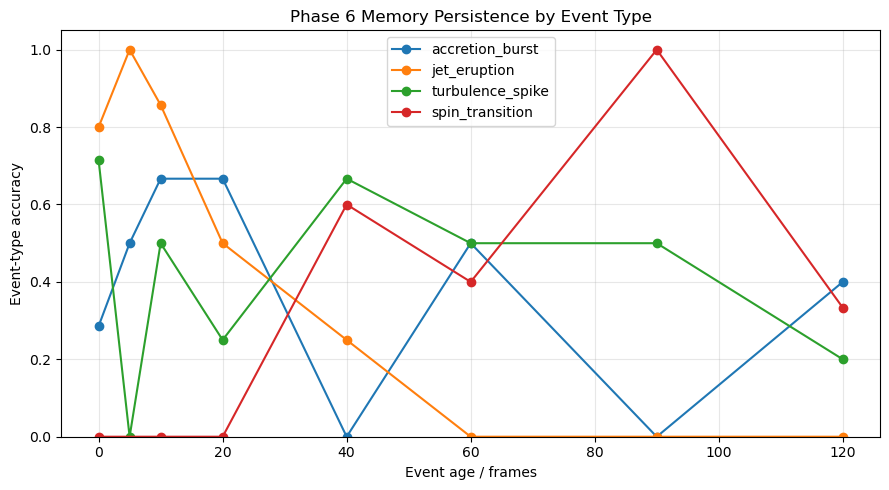

,accretion_burst,jet_eruption,turbulence_spike,spin_transition
accretion_burst,11,0,14,1
jet_eruption,5,16,9,4
turbulence_spike,7,5,13,4
spin_transition,5,3,7,8


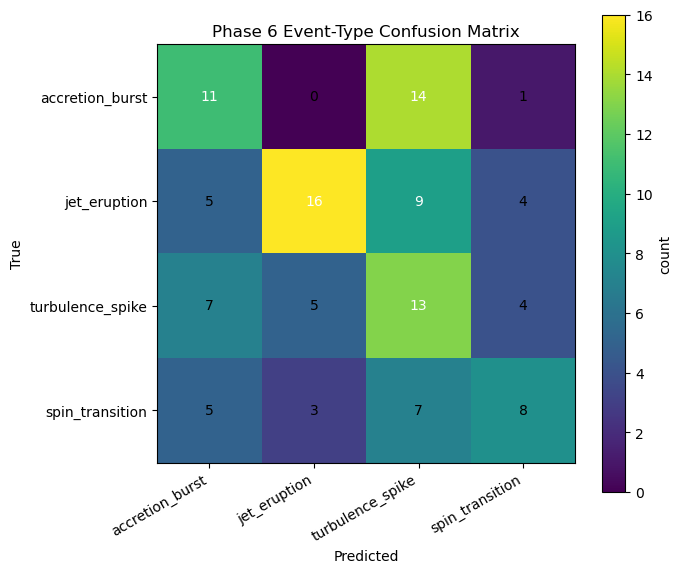

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6_memory_persistence/phase6_per_event_memory_curves_clean.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6_memory_persistence/phase6_per_event_memory_curves_clean.png
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6_memory_persistence/phase6_event_confusion_matrix_clean.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6_memory_persistence/phase6_event_confusion_matrix_clean.png


In [31]:
# ================================================================
# 17. Per-event curves and confusion matrix
# ================================================================

per_event_rows = []
for event_type in EVENT_TYPES:
    for age in sorted(pred_df["event_age"].unique()):
        subset = pred_df[(pred_df["true_event_type"] == event_type) & (pred_df["event_age"] == age)]
        if len(subset):
            per_event_rows.append({
                "event_type": event_type,
                "event_age": float(age),
                "type_accuracy": float(subset["correct_type"].mean()),
                "age_mae": float(subset["age_abs_error"].mean()),
                "n": int(len(subset)),
            })
per_event_df = pd.DataFrame(per_event_rows)
per_event_path = PHASE6_DIR / f"phase6_per_event_memory_curves_{INPUT_MODE}.csv"
per_event_df.to_csv(per_event_path, index=False)

plt.figure(figsize=(9, 5))
for event_type in EVENT_TYPES:
    sub = per_event_df[per_event_df["event_type"] == event_type]
    plt.plot(sub["event_age"].to_numpy(), sub["type_accuracy"].to_numpy(), marker="o", label=event_type)
plt.xlabel("Event age / frames")
plt.ylabel("Event-type accuracy")
plt.ylim(0, 1.05)
plt.title("Phase 6 Memory Persistence by Event Type")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
per_event_plot_path = PHASE6_DIR / f"phase6_per_event_memory_curves_{INPUT_MODE}.png"
plt.savefig(per_event_plot_path, dpi=150)
plt.show()

conf = np.zeros((len(EVENT_TYPES), len(EVENT_TYPES)), dtype=np.int32)
for t, p in zip(pred_df["true_type_index"], pred_df["pred_type_index"]):
    conf[int(t), int(p)] += 1
conf_df = pd.DataFrame(conf, index=EVENT_TYPES, columns=EVENT_TYPES)
conf_path = PHASE6_DIR / f"phase6_event_confusion_matrix_{INPUT_MODE}.csv"
conf_df.to_csv(conf_path)
display(conf_df)

plt.figure(figsize=(7, 6))
plt.imshow(conf, cmap="viridis")
plt.xticks(np.arange(len(EVENT_TYPES)), EVENT_TYPES, rotation=30, ha="right")
plt.yticks(np.arange(len(EVENT_TYPES)), EVENT_TYPES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Phase 6 Event-Type Confusion Matrix")
for i in range(conf.shape[0]):
    for j in range(conf.shape[1]):
        plt.text(j, i, str(conf[i, j]), ha="center", va="center", color="white" if conf[i, j] > conf.max()/2 else "black")
plt.colorbar(label="count")
plt.tight_layout()
conf_plot_path = PHASE6_DIR / f"phase6_event_confusion_matrix_{INPUT_MODE}.png"
plt.savefig(conf_plot_path, dpi=150)
plt.show()

print("Saved:", per_event_path)
print("Saved:", per_event_plot_path)
print("Saved:", conf_path)
print("Saved:", conf_plot_path)

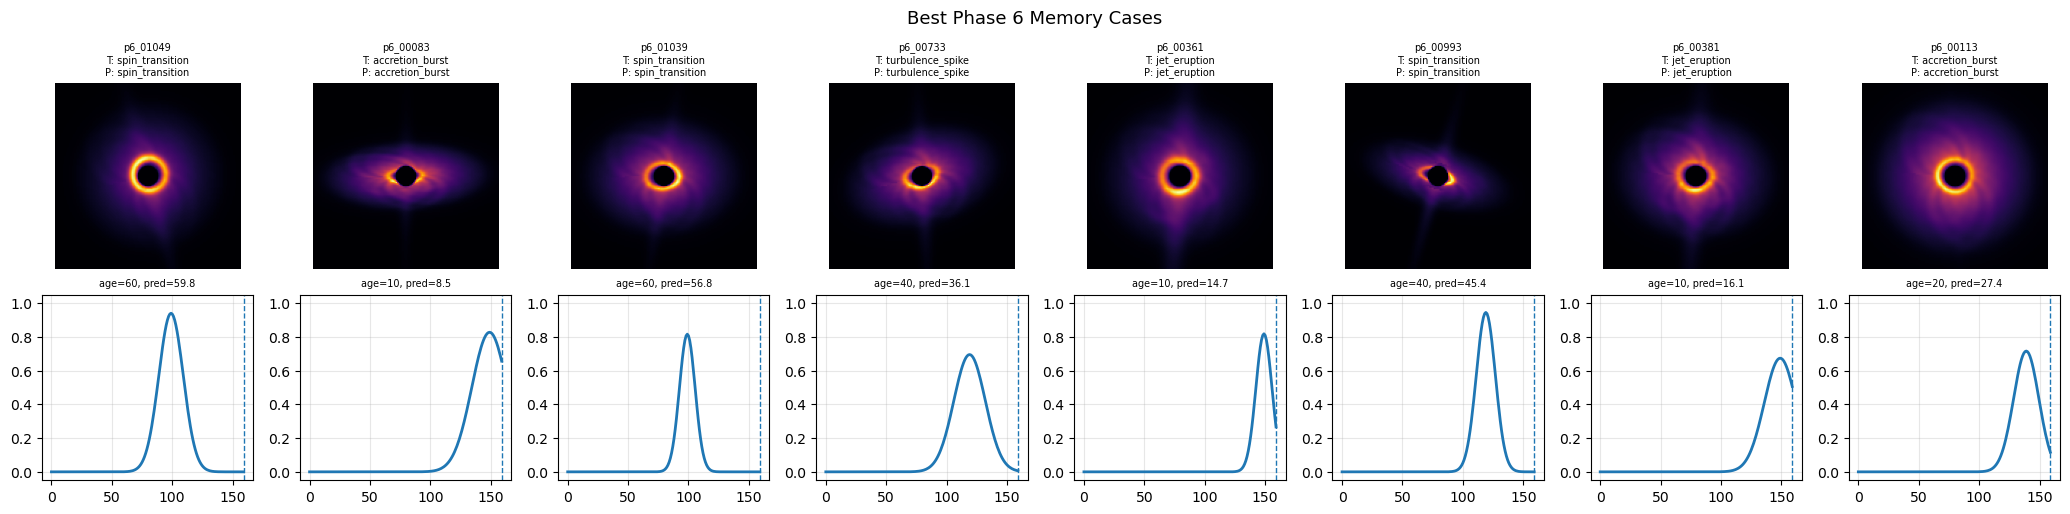

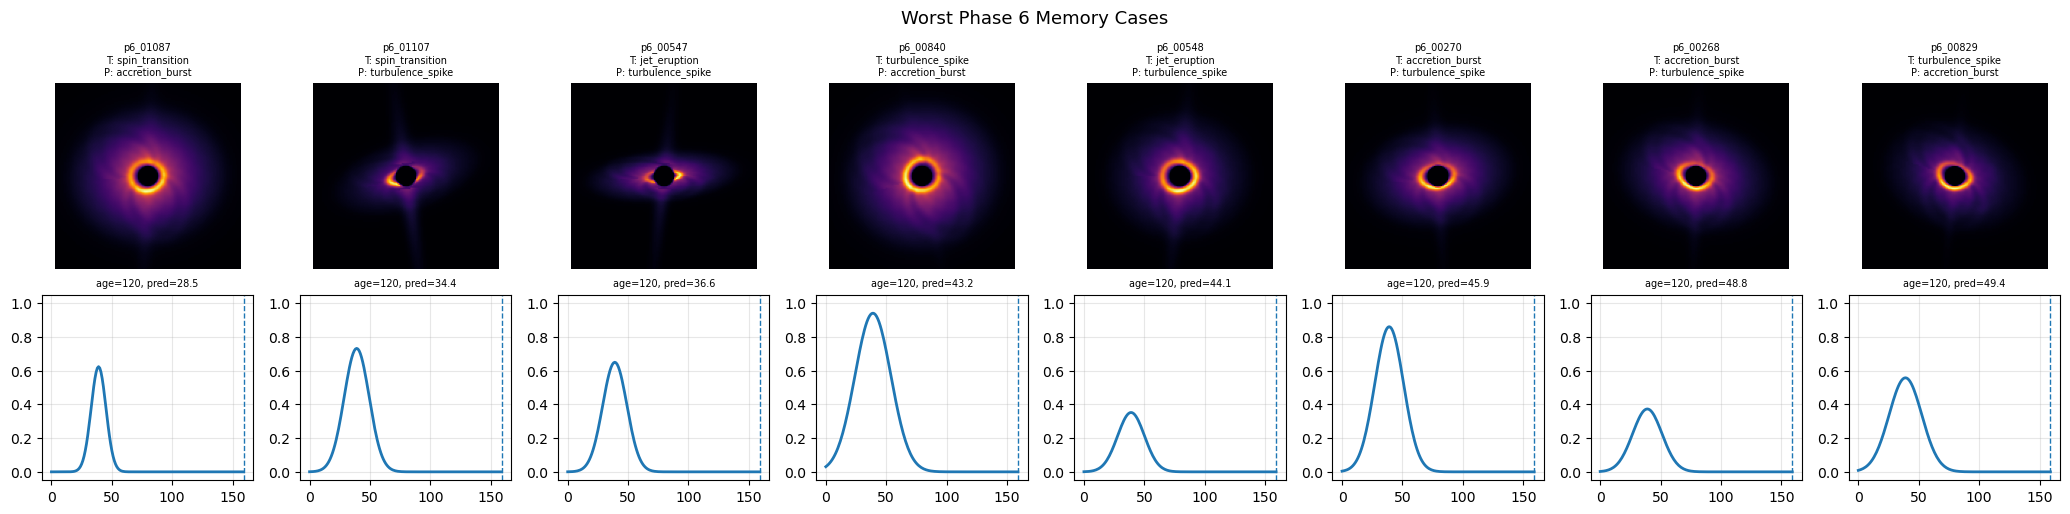


Phase 6 Summary — Physics-Based Memory Persistence

Dataset:
  /home/marwa/files/phase1_blackhole_generator/data/dataset_phase6_memory_persistence

Simulator source:
  /home/marwa/files/phase1_blackhole_generator/physics_blackhole_demo.py

Simulator SHA256:
  41e00c206e5f47711d06305ba4aff5aaa65802f846682288c5f5d78aa1a2ac2a

Input mode:
  clean

Events:
  ['accretion_burst', 'jet_eruption', 'turbulence_spike', 'spin_transition']

Event ages:
  [0, 5, 10, 20, 40, 60, 90, 120]

Samples:
  1120

Test performance:
  Event-type accuracy = 0.42188
  Event-age MAE       = 31.780 frames
  Event-age R2        = 0.15462

Estimated memory half-life:
  60.997 frames

Interpretation:
  Phase 6 turns the GPU black-hole simulator concept into a controlled
  memory-persistence experiment. It asks how long a past physical event
  remains observable in the final black-hole image.

  A decaying memory curve supports the existence of a finite observational
  memory horizon.

Recommended next step:
  Run t

In [32]:
# ================================================================
# 18. Best/worst examples and final summary
# ================================================================

best_cases = (
    pred_df
    .sort_values(["correct_type", "age_abs_error"], ascending=[False, True])
    .head(8)
)

worst_cases = (
    pred_df
    .sort_values(["correct_type", "age_abs_error"], ascending=[True, False])
    .head(8)
)

best_worst_path = PHASE6_DIR / f"phase6_best_worst_cases_{INPUT_MODE}.csv"

pd.concat([
    best_cases.assign(group="best"),
    worst_cases.assign(group="worst"),
]).to_csv(best_worst_path, index=False)


def image_path_for_case(sample_id, input_mode):
    if input_mode == "clean":
        return DATASET_DIR / "clean" / f"{sample_id}.png"

    if input_mode in ["noisy", "reconstructed"]:
        return DATASET_DIR / "noisy" / f"{sample_id}_noisy.png"

    raise ValueError(f"Unknown INPUT_MODE: {input_mode}")


def show_cases(case_df, title, n=8):
    case_df = case_df.head(n).copy()
    n_cases = len(case_df)

    if n_cases == 0:
        print(f"No cases to show for: {title}")
        return

    fig, axes = plt.subplots(
        2,
        n_cases,
        figsize=(2.6 * n_cases, 5.2),
        squeeze=False,
    )

    for i, (_, row) in enumerate(case_df.iterrows()):
        sid = str(row["sample_id"])

        image_path = image_path_for_case(sid, INPUT_MODE)
        history_path = DATASET_DIR / "history" / f"{sid}.csv"

        image = load_image01(image_path)
        hist = pd.read_csv(history_path)

        axes[0, i].imshow(
            image,
            cmap="inferno",
            vmin=0,
            vmax=1,
        )

        axes[0, i].set_title(
            f"{sid}\nT: {row['true_event_type']}\nP: {row['pred_event_type']}",
            fontsize=7,
        )

        axes[0, i].axis("off")

        axes[1, i].plot(
            hist["time"].to_numpy(),
            hist["event_profile"].to_numpy(),
            linewidth=2.0,
        )

        axes[1, i].axvline(
            HISTORY_T - 1,
            linestyle="--",
            linewidth=1,
        )

        axes[1, i].set_title(
            f"age={row['event_age']:.0f}, pred={row['pred_age']:.1f}",
            fontsize=7,
        )

        axes[1, i].set_ylim(-0.05, 1.05)
        axes[1, i].grid(alpha=0.3)

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


show_cases(best_cases, "Best Phase 6 Memory Cases")
show_cases(worst_cases, "Worst Phase 6 Memory Cases")


summary_text = f"""
Phase 6 Summary — Physics-Based Memory Persistence
==================================================

Dataset:
  {DATASET_DIR}

Simulator source:
  {GPU_SIMULATOR_PATH}

Simulator SHA256:
  {simulator_sha256}

Input mode:
  {INPUT_MODE}

Events:
  {EVENT_TYPES}

Event ages:
  {EVENT_AGES}

Samples:
  {len(params_df)}

Test performance:
  Event-type accuracy = {test_metrics['type_accuracy']:.5f}
  Event-age MAE       = {test_metrics['age_mae']:.3f} frames
  Event-age R2        = {test_metrics['age_r2']:.5f}

Estimated memory half-life:
  {memory_half_life:.3f} frames

Interpretation:
  Phase 6 turns the GPU black-hole simulator concept into a controlled
  memory-persistence experiment. It asks how long a past physical event
  remains observable in the final black-hole image.

  A decaying memory curve supports the existence of a finite observational
  memory horizon.

Recommended next step:
  Run this notebook once with INPUT_MODE='clean' and once with INPUT_MODE='noisy',
  then compare the memory half-life values.
"""

summary_path = PHASE6_DIR / f"phase6_summary_{INPUT_MODE}.txt"

with open(summary_path, "w") as f:
    f.write(summary_text)

print(summary_text)
print("Saved:", best_worst_path)
print("Saved:", summary_path)

In [33]:
import json
import pandas as pd

with open(
    PHASE6_DIR / "phase6_test_metrics_clean.json",
    "r"
) as f:
    clean_metrics = json.load(f)

with open(
    PHASE6_DIR / "phase6_test_metrics_noisy.json",
    "r"
) as f:
    noisy_metrics = json.load(f)

with open(
    PHASE6_DIR / "phase6_memory_half_life_summary_clean.json",
    "r"
) as f:
    clean_half = json.load(f)

with open(
    PHASE6_DIR / "phase6_memory_half_life_summary_noisy.json",
    "r"
) as f:
    noisy_half = json.load(f)

comparison_df = pd.DataFrame([
    {
        "mode": "clean",
        "type_accuracy": clean_metrics["type_accuracy"],
        "age_mae": clean_metrics["age_mae"],
        "age_r2": clean_metrics["age_r2"],
        "memory_half_life": clean_half["memory_half_life_frames"],
    },
    {
        "mode": "noisy",
        "type_accuracy": noisy_metrics["type_accuracy"],
        "age_mae": noisy_metrics["age_mae"],
        "age_r2": noisy_metrics["age_r2"],
        "memory_half_life": noisy_half["memory_half_life_frames"],
    },
])

display(comparison_df)

comparison_df.to_csv(
    PHASE6_DIR / "phase6_clean_vs_noisy_comparison.csv",
    index=False,
)

,mode,type_accuracy,age_mae,age_r2,memory_half_life
0,clean,0.421875,31.779893,0.154620,60.996952
1,noisy,0.406250,34.970855,0.023256,56.838069


/tmp/ipykernel_18239/1669506736.py:57: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return float(pearsonr(x, y).statistic)
/tmp/ipykernel_18239/1669506736.py:60: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return float(spearmanr(x, y).statistic)


,statistic,pearson_corr_with_event_age,spearman_corr_with_event_age,abs_pearson
10,texture_std,-0.171482,-0.152906,0.171482
8,disk_axis_mean,-0.119262,-0.101867,0.119262
6,outer_mean,-0.075756,-0.038494,0.075756
7,jet_axis_mean,-0.051624,-0.035284,0.051624
5,disk_mean,-0.045578,-0.031990,0.045578
0,mean_brightness,-0.042983,-0.027860,0.042983
3,center_mean,0.027148,0.018267,0.027148
2,std_brightness,-0.022766,-0.024652,0.022766
9,jet_to_disk_ratio,0.020875,0.010459,0.020875
4,ring_mean,-0.020398,-0.022650,0.020398


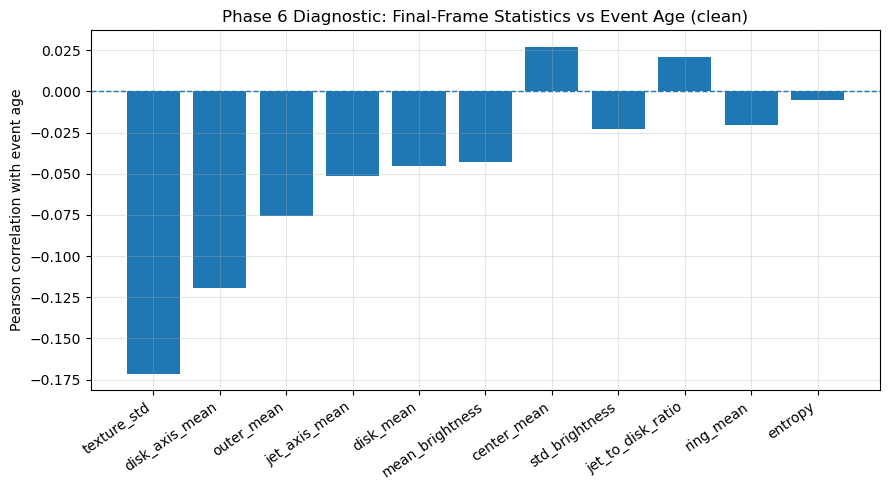

Saved image statistics: /home/marwa/files/phase1_blackhole_generator/outputs/phase6_memory_persistence/phase6_image_stat_age_diagnostic_clean.csv
Saved correlations: /home/marwa/files/phase1_blackhole_generator/outputs/phase6_memory_persistence/phase6_image_stat_age_correlations_clean.csv
Saved plot: /home/marwa/files/phase1_blackhole_generator/outputs/phase6_memory_persistence/phase6_image_stat_age_correlations_clean.png

Interpretation:
Event age has weak visibility in final-frame statistics. A stronger model may exploit some signal, but timestamp recovery is still intrinsically difficult.


In [34]:
# ================================================================
# 19. Diagnostic: Is event age visible in final-frame image statistics?
# ================================================================

from scipy.stats import pearsonr, spearmanr
from skimage.measure import shannon_entropy

def image_statistics(image):
    h, w = image.shape

    y, x = np.mgrid[-1:1:complex(h), -1:1:complex(w)]
    r = np.sqrt(x**2 + y**2)

    center_mask = r < 0.18
    ring_mask = (r >= 0.12) & (r <= 0.32)
    disk_mask = (r > 0.25) & (r < 0.75)
    outer_mask = r >= 0.75

    jet_axis_mask = (np.abs(x) < 0.08) & (np.abs(y) > 0.20)
    disk_axis_mask = (np.abs(y) < 0.12) & (np.abs(x) > 0.18)

    stats = {
        "mean_brightness": float(image.mean()),
        "max_brightness": float(image.max()),
        "std_brightness": float(image.std()),
        "center_mean": float(image[center_mask].mean()),
        "ring_mean": float(image[ring_mask].mean()),
        "disk_mean": float(image[disk_mask].mean()),
        "outer_mean": float(image[outer_mask].mean()),
        "jet_axis_mean": float(image[jet_axis_mask].mean()),
        "disk_axis_mean": float(image[disk_axis_mask].mean()),
        "jet_to_disk_ratio": float(
            image[jet_axis_mask].mean() / (image[disk_axis_mask].mean() + 1e-8)
        ),
        "texture_std": float(image[disk_mask].std()),
        "entropy": float(shannon_entropy(image)),
    }

    return stats


def safe_corr(x, y, method="pearson"):
    x = np.asarray(x, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 3:
        return np.nan

    if np.std(x) < 1e-8 or np.std(y) < 1e-8:
        return np.nan

    if method == "pearson":
        return float(pearsonr(x, y).statistic)

    if method == "spearman":
        return float(spearmanr(x, y).statistic)

    raise ValueError(f"Unknown method: {method}")


stat_rows = []

for _, row in params_df.iterrows():
    sid = str(row["sample_id"])

    if INPUT_MODE == "clean":
        image_path = DATASET_DIR / "clean" / f"{sid}.png"
    elif INPUT_MODE == "noisy":
        image_path = DATASET_DIR / "noisy" / f"{sid}_noisy.png"
    else:
        raise ValueError(f"Unsupported INPUT_MODE for this diagnostic: {INPUT_MODE}")

    image = load_image01(image_path)
    stats = image_statistics(image)

    stats.update({
        "sample_id": sid,
        "event_type": row["event_type"],
        "event_age": float(row["event_age"]),
    })

    stat_rows.append(stats)

image_stats_df = pd.DataFrame(stat_rows)

diagnostic_path = PHASE6_DIR / f"phase6_image_stat_age_diagnostic_{INPUT_MODE}.csv"
image_stats_df.to_csv(diagnostic_path, index=False)

stat_columns = [
    col for col in image_stats_df.columns
    if col not in ["sample_id", "event_type", "event_age"]
]

corr_rows = []

for col in stat_columns:
    corr_rows.append({
        "statistic": col,
        "pearson_corr_with_event_age": safe_corr(
            image_stats_df[col],
            image_stats_df["event_age"],
            method="pearson",
        ),
        "spearman_corr_with_event_age": safe_corr(
            image_stats_df[col],
            image_stats_df["event_age"],
            method="spearman",
        ),
        "abs_pearson": abs(
            safe_corr(
                image_stats_df[col],
                image_stats_df["event_age"],
                method="pearson",
            )
        ),
    })

corr_df = pd.DataFrame(corr_rows).sort_values(
    "abs_pearson",
    ascending=False,
)

corr_path = PHASE6_DIR / f"phase6_image_stat_age_correlations_{INPUT_MODE}.csv"
corr_df.to_csv(corr_path, index=False)

display(corr_df)

plt.figure(figsize=(9, 5))
plt.bar(
    corr_df["statistic"],
    corr_df["pearson_corr_with_event_age"],
)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Pearson correlation with event age")
plt.title(f"Phase 6 Diagnostic: Final-Frame Statistics vs Event Age ({INPUT_MODE})")
plt.grid(alpha=0.3)
plt.tight_layout()

corr_plot_path = PHASE6_DIR / f"phase6_image_stat_age_correlations_{INPUT_MODE}.png"
plt.savefig(corr_plot_path, dpi=150)
plt.show()

print("Saved image statistics:", diagnostic_path)
print("Saved correlations:", corr_path)
print("Saved plot:", corr_plot_path)

max_abs_corr = corr_df["abs_pearson"].max()

print("\nInterpretation:")
if max_abs_corr < 0.10:
    print(
        "Event age is almost not visible in simple final-frame image statistics. "
        "This supports the conclusion that age recovery is information-limited."
    )
elif max_abs_corr < 0.25:
    print(
        "Event age has weak visibility in final-frame statistics. "
        "A stronger model may exploit some signal, but timestamp recovery is still intrinsically difficult."
    )
else:
    print(
        "Event age has measurable visibility in final-frame statistics. "
        "If age prediction remains poor, the bottleneck may be architectural or training-related."
    )

## Final conclusion

Phase 6 is a new scientific angle, not another dataset tweak.

The central result is the shape of:

```text
recoverability(event_age)
```

If the curve decays, you have evidence for a finite memory horizon. If different event types decay at different rates, the project gains a much stronger publishable hypothesis:

> Different black-hole dynamical processes leave observational memory signatures with different persistence timescales.